This notebook presents results from classifying galaxy images from Galaxy Zoo 2 (GZ2), a citizen science project that helps classify galaxies from the Sloan Digital Sky Survey (SDSS).

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import scipy
from skimage.transform import rescale, resize, downscale_local_mean
from time import time
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import random
from torch.utils.data import Dataset, DataLoader

/Users/alifazal/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/alifazal/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c106detail19maybe_wrap_dim_slowIxEET_S2_S2_b
  Referenced from: <E03EDA44-89AE-3115-9796-62BA9E0E2EDE> /Users/alifazal/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <F2FE5CF8-5B5B-3FAD-ADF8-C77D90F49FC9> /Users/alifazal/anaconda3/lib/python3.11/site-packages/torch/lib/libc10.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
np.random.seed(42); torch.manual_seed(42)

# Training Data Inspection

In [3]:
training_images = os.listdir('data/training_images')

In [4]:
# number of images
training_size = len(training_images)
print(training_size)

61578


In [16]:
training_directory = 'data/training_images/'

Image Dimension: (424, 424, 3)


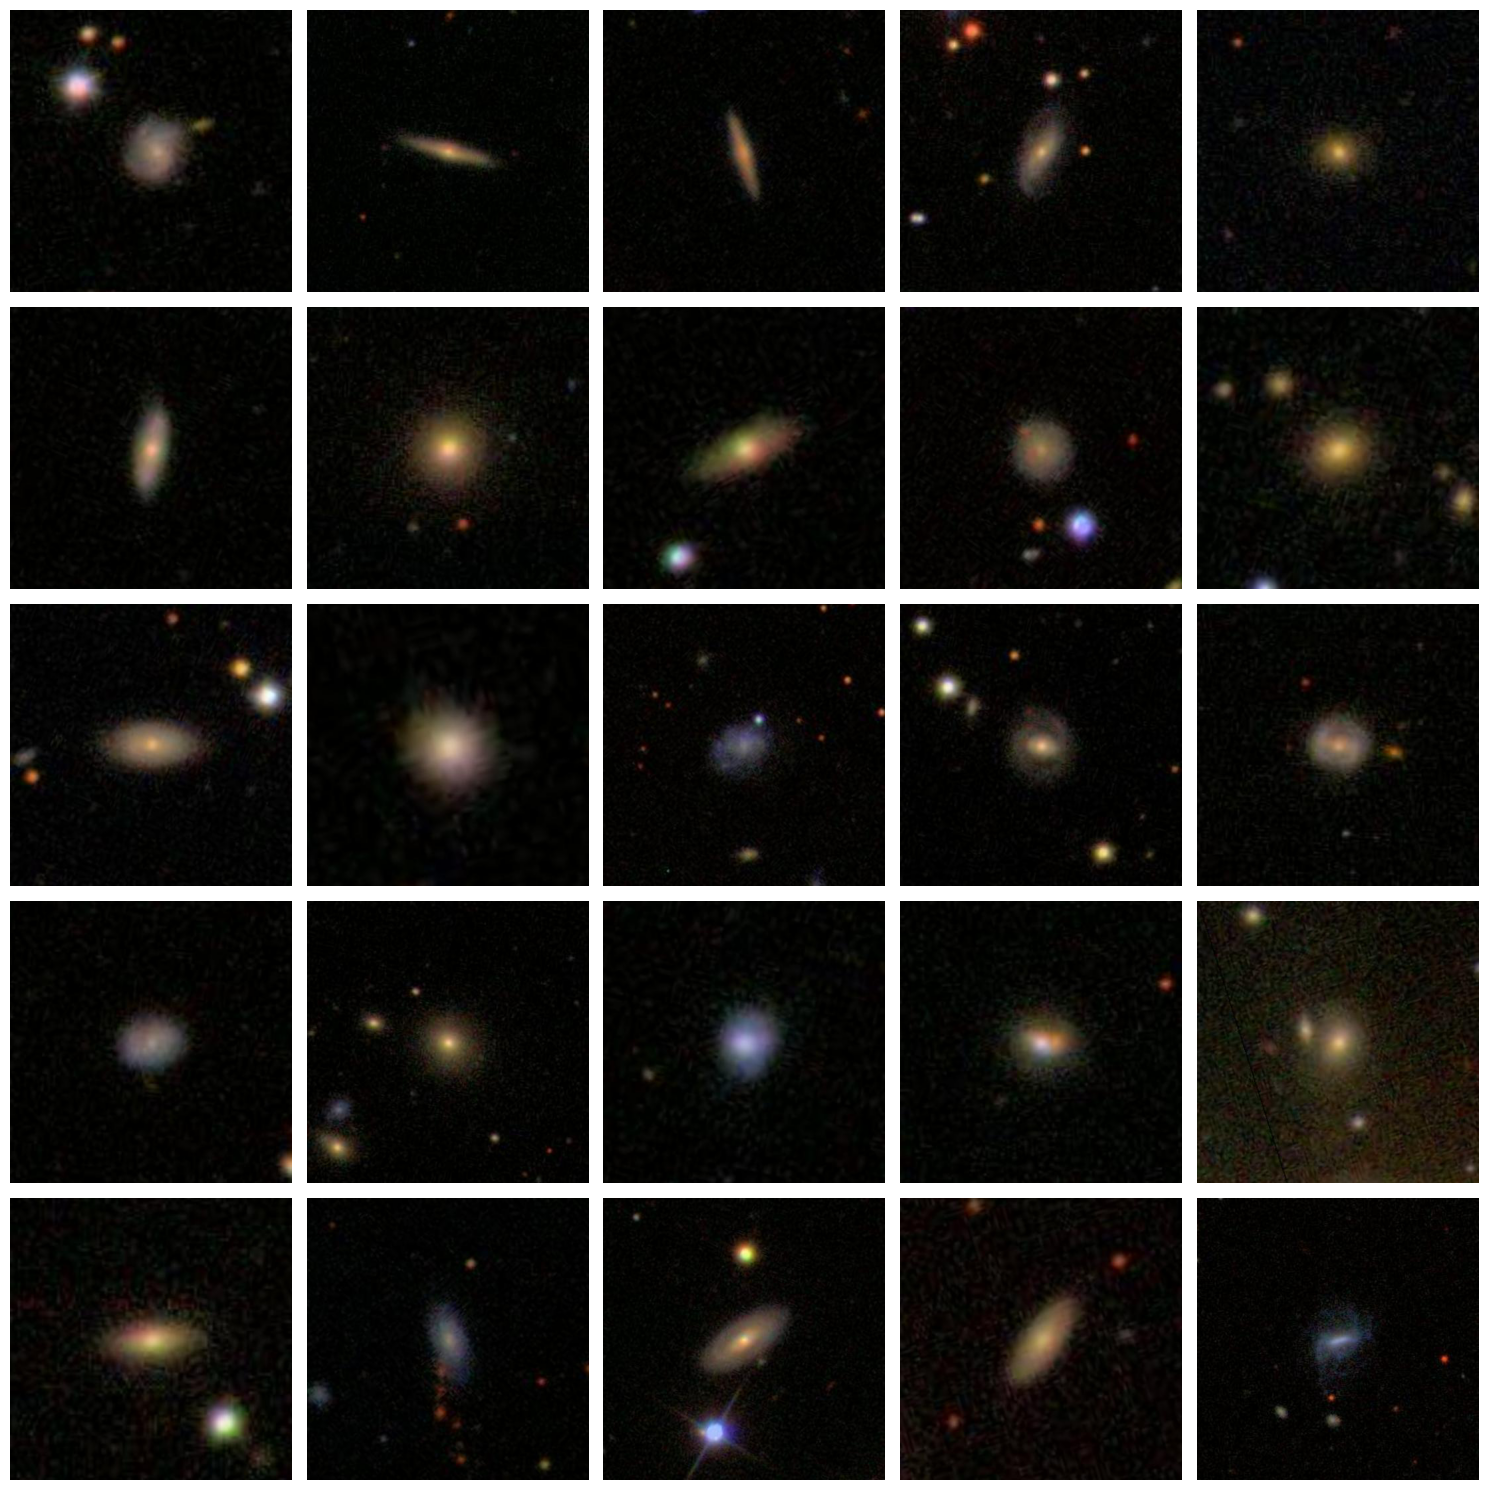

In [ ]:
random_indices = np.random.randint(low=0, high=training_size-1, size=25)

fig, ax = plt.subplots(5, 5, figsize=(15,15))
for i, idx in enumerate(random_indices):
    row = i//5; col = i%5
    image = img.imread(training_directory+training_images[idx])
    ax[row, col].imshow(image)
    ax[row, col].axis('off')
fig.tight_layout()
print("Image Dimension:", image.shape)


In [2]:
training_labels = pd.read_csv('data/training_classifications.csv')

In [3]:
# label classifications with likelihoods
training_labels.head()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [4]:
label_names = np.array(training_labels.columns[1:]).astype(str)

In [5]:
print(label_names)

['Class1.1' 'Class1.2' 'Class1.3' 'Class2.1' 'Class2.2' 'Class3.1'
 'Class3.2' 'Class4.1' 'Class4.2' 'Class5.1' 'Class5.2' 'Class5.3'
 'Class5.4' 'Class6.1' 'Class6.2' 'Class7.1' 'Class7.2' 'Class7.3'
 'Class8.1' 'Class8.2' 'Class8.3' 'Class8.4' 'Class8.5' 'Class8.6'
 'Class8.7' 'Class9.1' 'Class9.2' 'Class9.3' 'Class10.1' 'Class10.2'
 'Class10.3' 'Class11.1' 'Class11.2' 'Class11.3' 'Class11.4' 'Class11.5'
 'Class11.6']


In [24]:
label_descriptions = {
    label_names[0]:'smooth',
    label_names[1]:'features or disk',
    label_names[2]:'star or artifact',
    label_names[3]:'edge-on',
    label_names[4]:'no edge-on',
    label_names[5]:'bar',
    label_names[6]:'no bar',
    label_names[7]:'spiral arm',
    label_names[8]:'no spiral arm',
    label_names[9]:'no bulge',
    label_names[10]:'just noticeable',
    label_names[11]:'obvious',
    label_names[12]:'dominant',
    label_names[13]:'odd',
    label_names[14]:'no odd',
    label_names[15]:'completely round',
    label_names[16]:'in between',
    label_names[17]:'cigar-shaped',
    label_names[18]:'ring',
    label_names[19]:'lens or arc',
    label_names[20]:'disturbed',
    label_names[21]:'irregular',
    label_names[22]:'other',
    label_names[23]:'merger',
    label_names[24]:'dust lane',
    label_names[25]:'rounded',
    label_names[26]:'boxy',
    label_names[27]:'no bulge',
    label_names[28]:'tight',
    label_names[29]:'medium',
    label_names[30]:'loose',
    label_names[31]:'1 arm',
    label_names[32]:'2 arms',
    label_names[33]:'3 arms',
    label_names[34]:'4 arms',
    label_names[35]:'5+ arms',
    label_names[36]:'can\'t tell',
}

# EDA
## Image and Label Inspection

Label Histograms


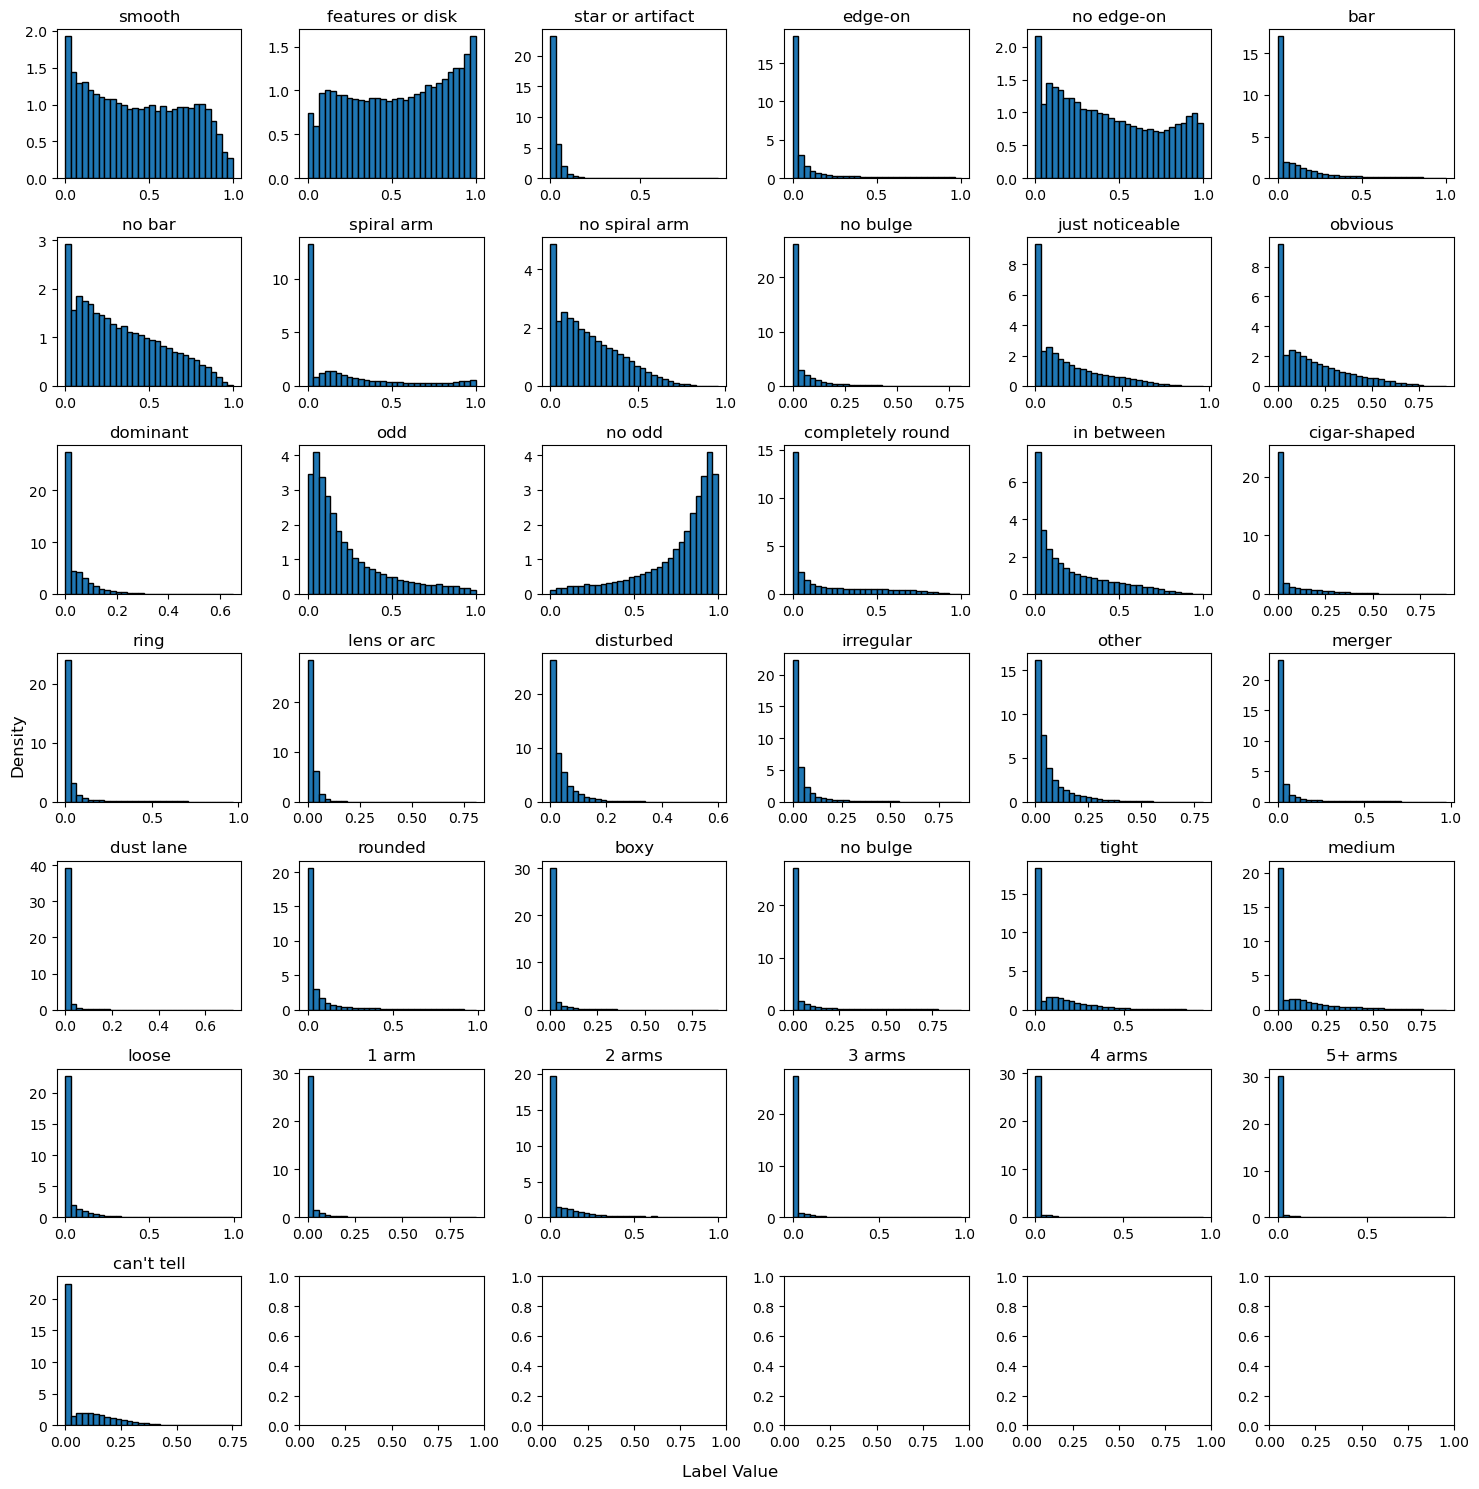

In [25]:
fig, ax = plt.subplots(7, 6, figsize=(15,15)); ax = ax.ravel()
for i, label in enumerate(label_names):
    ax[i].hist(training_labels[label], density=True, bins=30, edgecolor='black')
    ax[i].set_title(label_descriptions[label])

fig.supxlabel('Label Value')
fig.supylabel('Density')

fig.tight_layout()
#fig.savefig('lab3_figures/fig2.png')
print("Label Histograms")

Images of Labels with Highest Probabilities


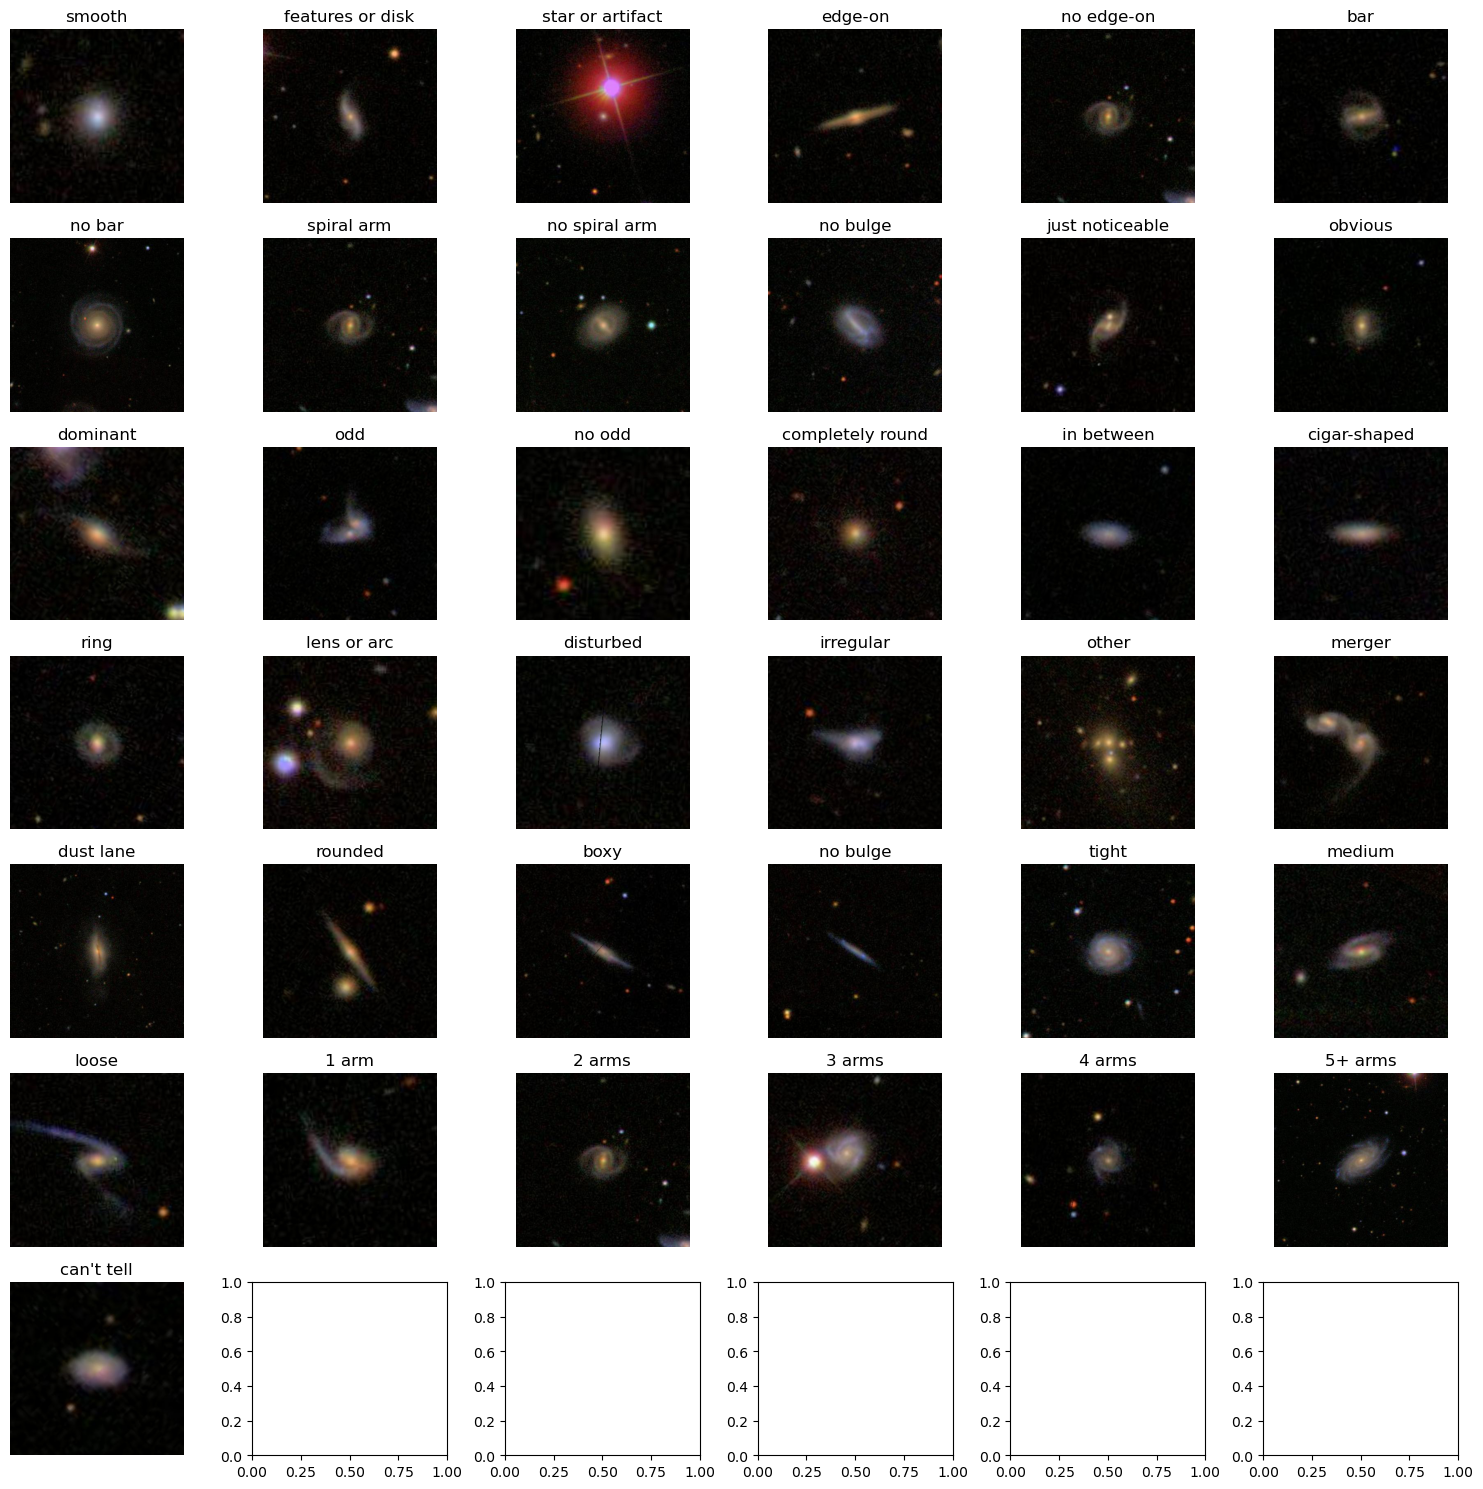

In [26]:
fig, ax = plt.subplots(7, 6, figsize=(15,15)); ax = ax.ravel()
for i, label in enumerate(label_names):
    max_index = np.argmax(training_labels[label])
    galaxy_ID = str(training_labels['GalaxyID'][max_index])
    image = img.imread(training_directory+galaxy_ID+'.jpg')
    ax[i].imshow(image)
    ax[i].axis('off')
    ax[i].set_title(label_descriptions[label])
fig.tight_layout()
print("Images of Labels with Highest Probabilities")

In [27]:
corr_matrix = training_labels[label_names].corr(method='pearson')

Label Correlation Matrix


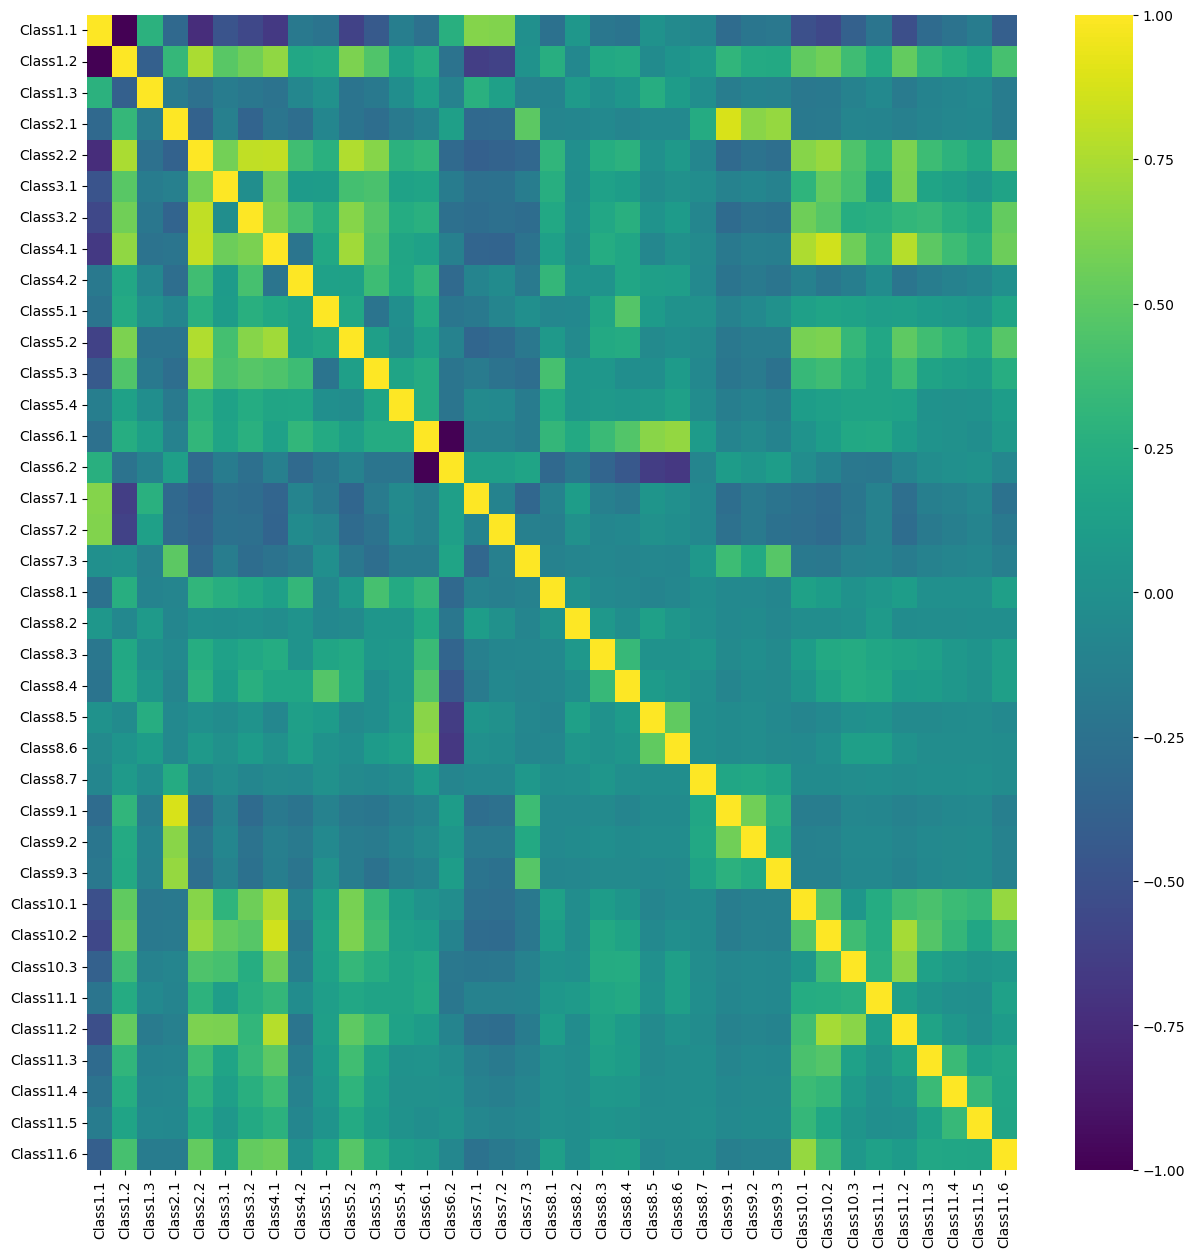

In [28]:
# plot the correlaation matrix for all 37 labels
fig, ax = plt.subplots(1, figsize=(15,15))
sns.heatmap(corr_matrix, ax=ax, cmap='viridis')
print("Label Correlation Matrix")

In [29]:
classes = np.arange(1, 12)
class_masks = {}

for class_num in classes:
    val_list = []
    for label in label_names:
        if label.split('.')[0] == f'Class{class_num}':
            val_list.append(label)
        class_masks[class_num] = val_list

Class Correlation Matrix


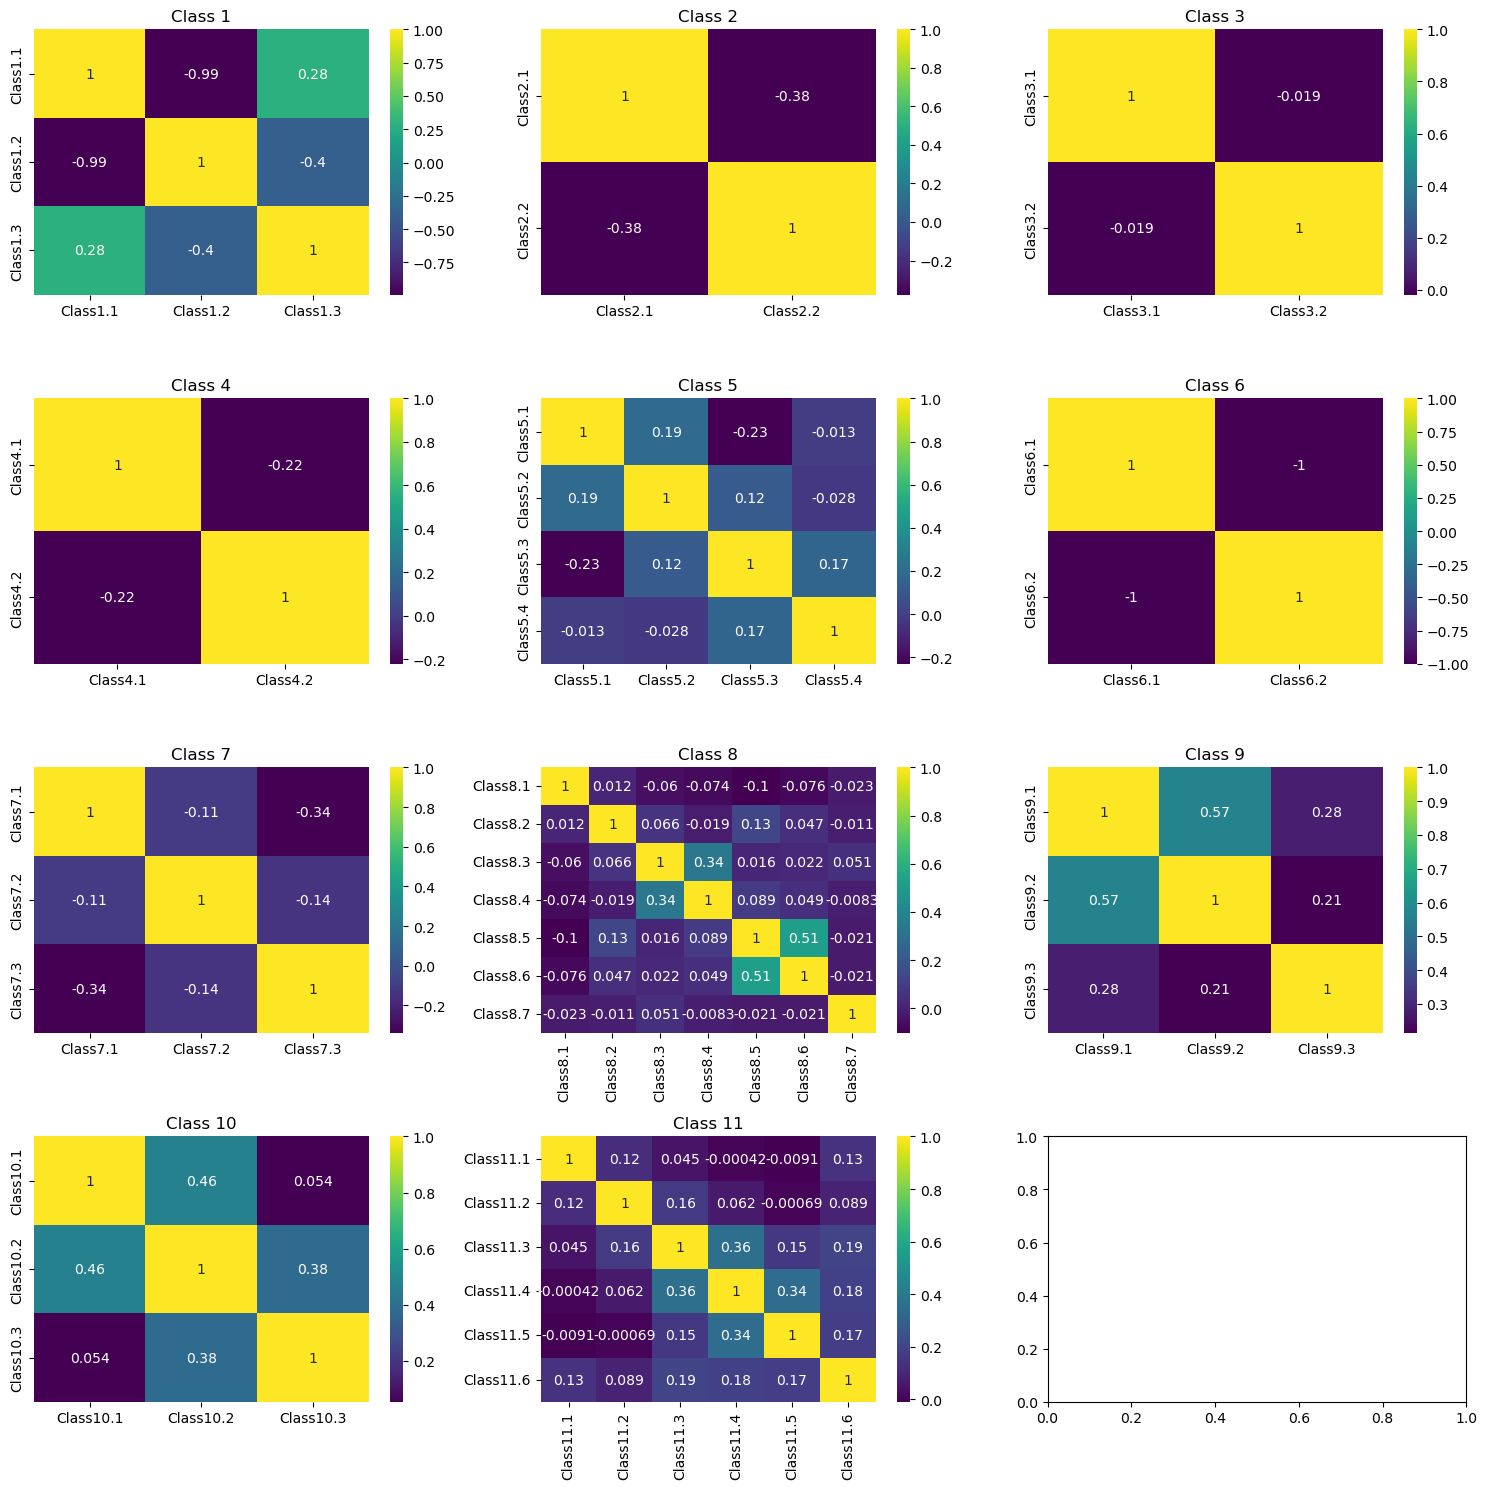

In [30]:
# plot the correlation matrix for all 11 classes
fig, ax = plt.subplots(4,3, figsize=(15,15)); ax = ax.ravel()
for i, class_num in enumerate(classes):
    class_corr_matrix = corr_matrix.loc[class_masks[class_num], class_masks[class_num]]
    sns.heatmap(class_corr_matrix, ax=ax[i], cmap='viridis', annot=True)
    ax[i].set_title(f'Class {class_num}')

fig.tight_layout()
#fig.savefig('lab3_figures/fig5.png')
print("Class Correlation Matrix")

# Downsizing and Batching Data to Save Memory

In [31]:
# downsizing images

def downsize(image, margin=60, rescale_factor=6):
    '''
    image is pixel array
    '''
    cropped_image = image[margin:-margin, margin:-margin]
    
    # next, resample into a coarser pixe; grid
    downsized_image = rescale(cropped_image, 1/np.sqrt(rescale_factor), anti_aliasing=True, channel_axis=-1) 
    
    return downsized_image

In [32]:
# downsizing images then saving them into a new folder
def downsize_all_images():
    for i in tqdm(range(training_size)):
        image_name = training_images[i]
        image = img.imread(training_directory+image_name)
        downsized_image = downsize(image)
        plt.imsave(f"data/training_images_downsized/{image_name}_downsized.jpg", downsized_image)

In [33]:
downsize_all_images()

100%|██████████| 61578/61578 [12:23<00:00, 82.84it/s]


In [34]:
training_images_downsized = os.listdir("data/training_images_downsized")

In [35]:
downsized_directory = 'data/training_images_downsized/'

Image Dimension: (124, 124, 3)


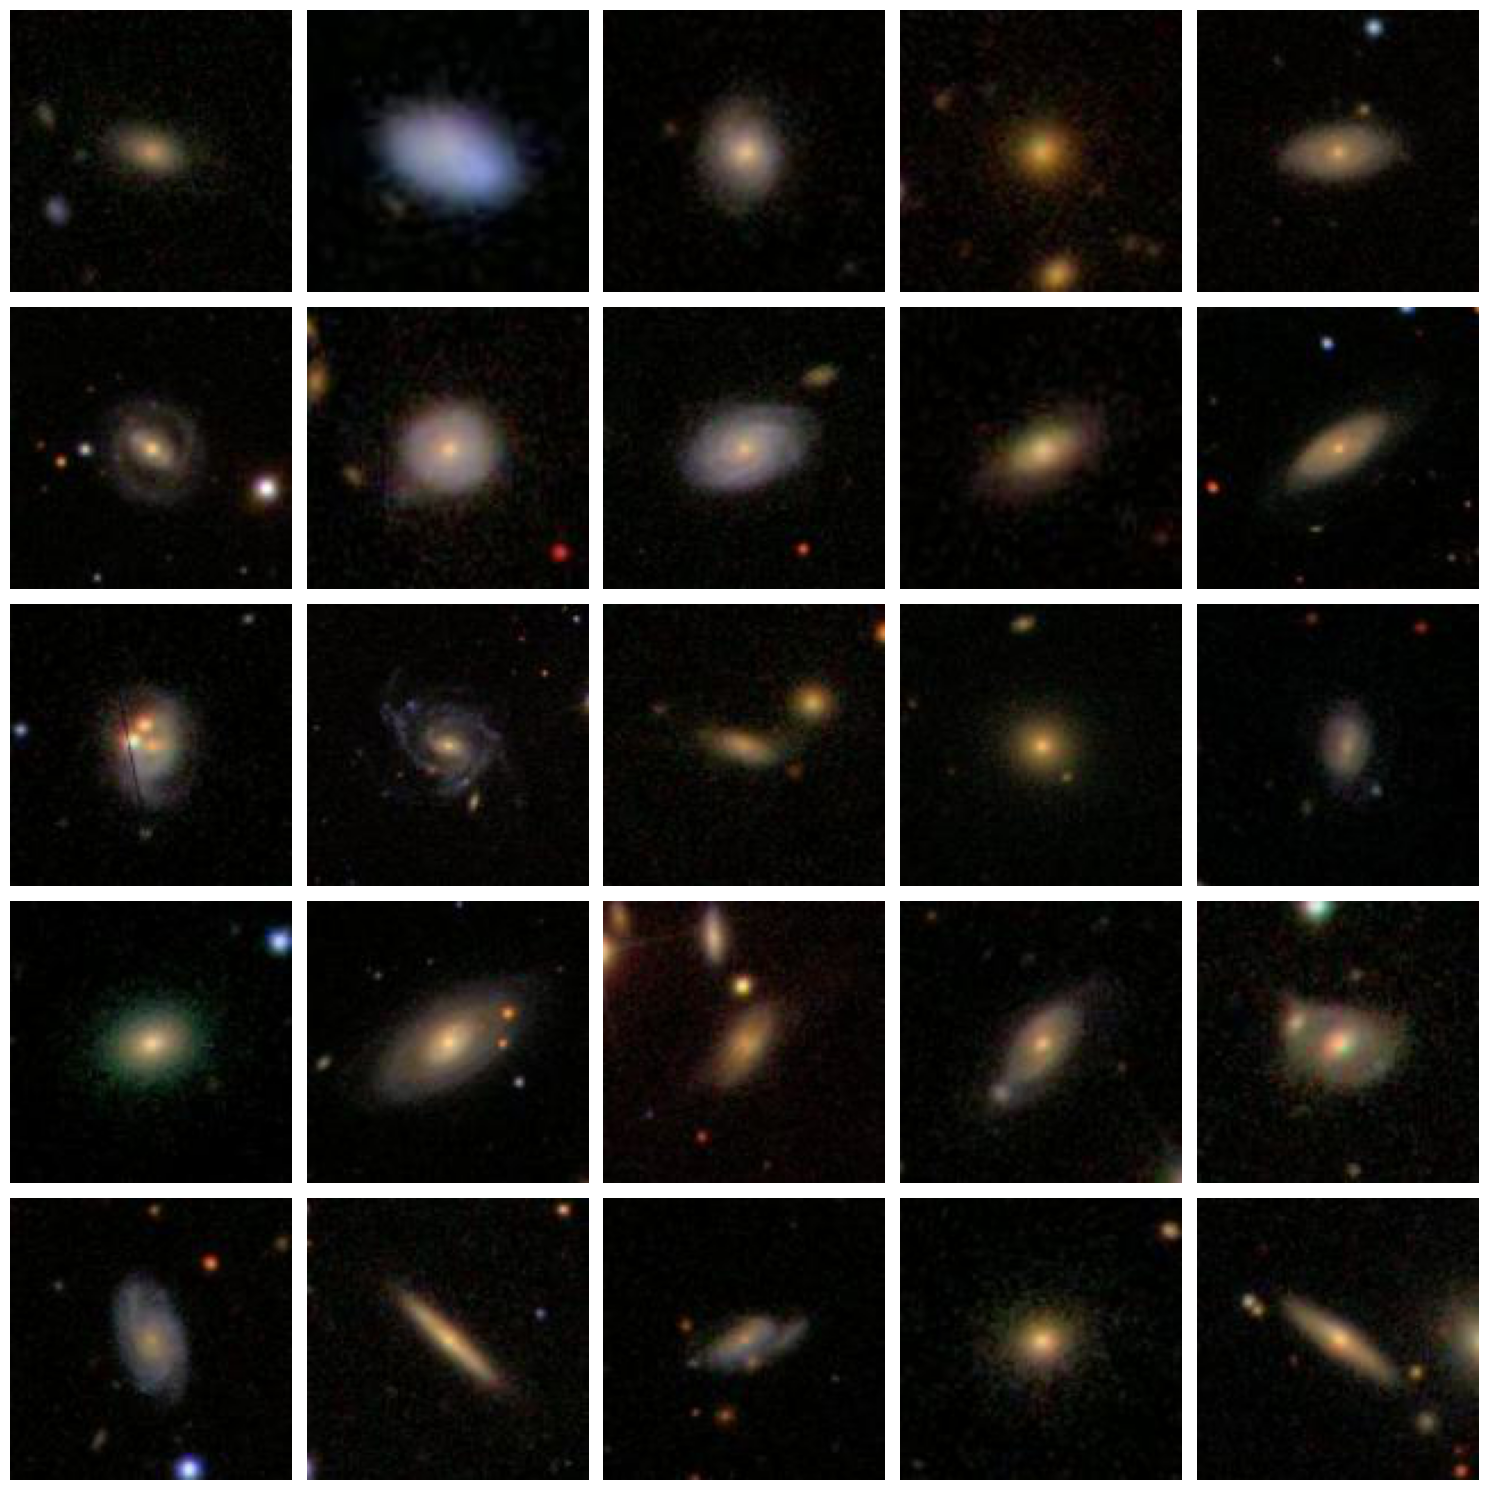

In [42]:
random_indices = np.random.randint(low=0, high=training_size-1, size=25)

fig, ax = plt.subplots(5, 5, figsize=(15,15))
for i, idx in enumerate(random_indices):
    row = i//5; col = i%5
    image = img.imread(downsized_directory+training_images_downsized[idx])
    ax[row, col].imshow(image)
    ax[row, col].axis('off')
fig.tight_layout()
print("Image Dimension:", image.shape)


In [37]:
label_mapping = {i:label_descriptions[label_names[i]] for i in range(len(label_names))}

# Evaluating after training on Collab with GPU

In [59]:
def evaluate_on_gpu(model, data_loader, device='cuda'):
    """
    Evaluate model on dataset using GPU
    
    Args:
        model: Trained model
        data_loader: DataLoader for evaluation
        device: 'cuda' or 'cpu'
    
    Returns:
        predictions: numpy array of predictions
        targets: numpy array of actual labels
    """
    model = model.to(device)
    model.eval()
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)
            
            # Move to CPU for storage
            all_predictions.append(outputs.cpu().numpy())
            all_targets.append(labels.numpy())
    
    predictions = np.vstack(all_predictions)
    targets = np.vstack(all_targets)
    
    return predictions, targets

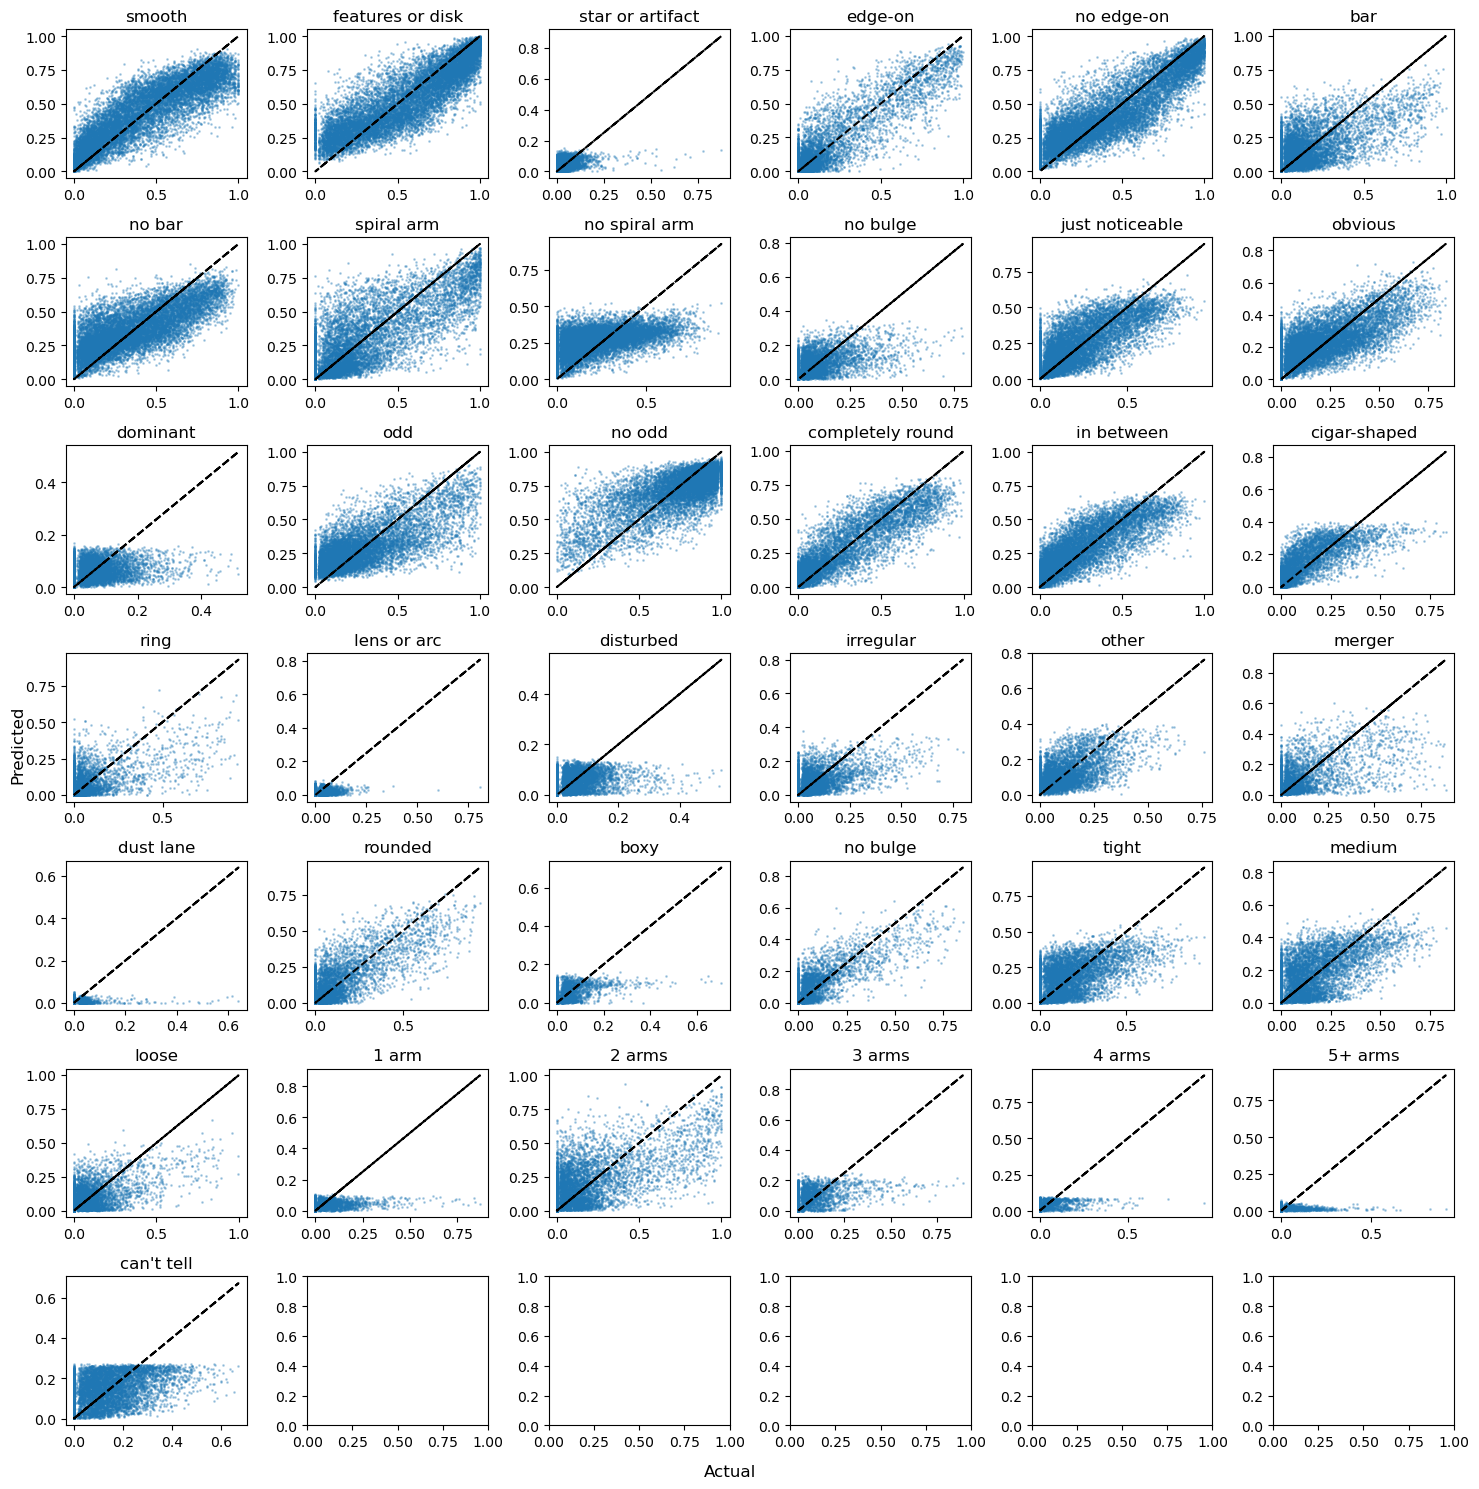

In [66]:
# using custom CNN
fig, ax = plt.subplots(7, 6, figsize=(15,15)); ax = ax.ravel()

for i, label in enumerate(label_names):
    actual = val[label].values
    pred = predicted[:,i]
    
    ax[i].scatter(actual, pred, s=1, alpha=0.3)
    ax[i].plot(actual, actual, '--', color='black')
    ax[i].set_title(label_descriptions[label])


fig.supxlabel('Actual')
fig.supylabel('Predicted')
fig.tight_layout()

#fig.savefig('lab3_data/fig12.png')